In [1]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()


In [2]:
def load_world_bank_indicator(csv_path: Path, value_name: str) -> pd.DataFrame:
    """Load a World Bank wide-format CSV and return long format.

    Output columns: Country Name, Country Code, Year, <value_name>.
    """
    df = pd.read_csv(csv_path, skiprows=4)

    id_cols = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]
    year_cols = [c for c in df.columns if c not in id_cols]

    long_df = df.melt(
        id_vars=["Country Name", "Country Code"],
        value_vars=year_cols,
        var_name="Year",
        value_name=value_name,
    )

    long_df["Year"] = pd.to_numeric(long_df["Year"], errors="coerce")
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors="coerce")

    long_df = long_df.dropna(subset=["Year"])
    long_df["Year"] = long_df["Year"].astype(int)

    return long_df


def load_water_access(csv_path: Path) -> pd.DataFrame:
    """Load safely managed drinking water data (Our World in Data)."""
    df = pd.read_csv(csv_path)

    df = df.rename(
        columns={
            "Entity": "Country Name",
            "Code": "Country Code",
            "Year": "Year",
            "Share of the population using safely managed drinking water": "safe_water_access_pct",
        }
    )

    # Keep only rows that have an ISO-style country code (3 letters)
    df = df[df["Country Code"].str.len() == 3]

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype(int)
    df["safe_water_access_pct"] = pd.to_numeric(
        df["safe_water_access_pct"], errors="coerce"
    )

    return df[["Country Name", "Country Code", "Year", "safe_water_access_pct"]]


def build_dataset() -> pd.DataFrame:
    """Merge GDP per capita, access to electricity, and safe water access."""
    gdp_path = BASE_DIR / "API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv"
    elec_path = BASE_DIR / "API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_158.csv"
    water_path = BASE_DIR / "proportion-using-safely-managed-drinking-water.csv"

    gdp = load_world_bank_indicator(gdp_path, "gdp_per_capita")
    elec = load_world_bank_indicator(elec_path, "access_to_electricity_pct")
    water = load_water_access(water_path)

    merged = water.merge(
        gdp[["Country Code", "Year", "gdp_per_capita"]],
        on=["Country Code", "Year"],
        how="inner",
    )
    merged = merged.merge(
        elec[["Country Code", "Year", "access_to_electricity_pct"]],
        on=["Country Code", "Year"],
        how="inner",
    )

    merged = merged.dropna(subset=["safe_water_access_pct"])

    return merged


In [3]:
df = build_dataset()
df.head()


,Country Name,Country Code,Year,safe_water_access_pct,gdp_per_capita,access_to_electricity_pct
0,Afghanistan,AFG,2000,11.483052,174.930991,4.4
1,Afghanistan,AFG,2001,11.495201,138.706822,9.3
2,Afghanistan,AFG,2002,12.298100,178.954088,14.1
3,Afghanistan,AFG,2003,13.100750,198.871116,19.0
4,Afghanistan,AFG,2004,13.910267,221.763654,23.8


In [4]:
print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum())

df.describe()[["gdp_per_capita", "access_to_electricity_pct", "safe_water_access_pct"]]


Shape: (3716, 6)

Missing values per column:
Country Name                   0
Country Code                   0
Year                           0
safe_water_access_pct          0
gdp_per_capita                96
access_to_electricity_pct    183
dtype: int64


,gdp_per_capita,access_to_electricity_pct,safe_water_access_pct
count,3620.000000,3533.000000,3716.000000
mean,17995.019171,85.130059,67.001839
std,27235.444289,26.715921,30.950898
min,109.593814,1.300000,1.283958
25%,1823.170491,85.500000,42.789042
50%,6062.122515,99.700000,75.482928
75%,24942.731702,100.000000,96.662191
max,288001.433369,100.000000,100.000000


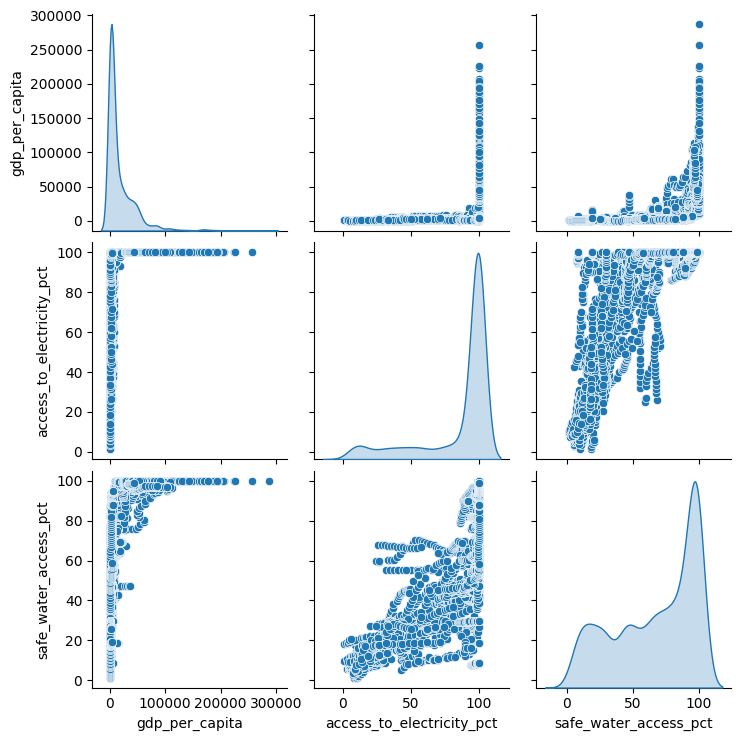

In [5]:
sns.pairplot(
    df[["gdp_per_capita", "access_to_electricity_pct", "safe_water_access_pct"]],
    diag_kind="kde"
)
plt.show()


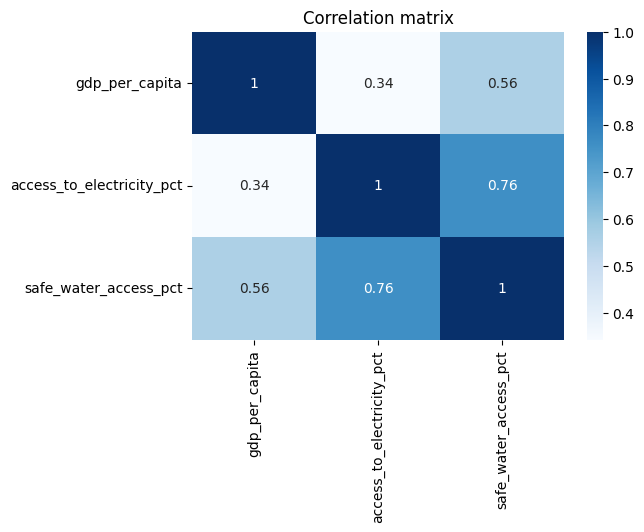

In [6]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df[["gdp_per_capita", "access_to_electricity_pct", "safe_water_access_pct"]].corr(),
    annot=True,
    cmap="Blues",
)
plt.title("Correlation matrix")
plt.show()


In [7]:
feature_cols = ["gdp_per_capita", "access_to_electricity_pct"]
target_col = "safe_water_access_pct"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

len(X_train), len(X_test)


(2972, 744)

In [8]:
def make_pipeline(model):
    return Pipeline(
        steps=[
            ("imputer", KNNImputer(n_neighbors=3)),
            ("scaler", StandardScaler()),
            ("model", model),
        ]
    )


models = {
    "LinearRegression": make_pipeline(LinearRegression()),
    "RandomForest": make_pipeline(
        RandomForestRegressor(n_estimators=300, random_state=42)
    ),
}

results = {}
best_model_name = None
best_model = None
best_r2 = -np.inf

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n{name}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE : {mae:.3f}")
    print(f"  R2  : {r2:.3f}")

    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name
        best_model = model

print(f"\nBest model: {best_model_name} (R2 = {best_r2:.3f})")


TypeError: got an unexpected keyword argument 'squared'

In [ ]:
models_dir = BASE_DIR / "models"
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "best_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump({"model": best_model, "feature_cols": feature_cols}, f)

model_path
